# Vibroacoustics — aluminium CCCC plate on a closed cavity

A flexible plate closes an air-filled box. The plate radiates into the cavity, the
cavity pushes back: neither problem is right on its own. This notebook runs the
**coupled** problem end to end, twice over:

1. a **modal analysis** — the natural frequencies and mode shapes of the coupled
   fluid–structure system;
2. a **direct frequency response** — the forced response solved frequency by
   frequency on the full coupled matrix,

and then checks one against the other: every peak of the direct sweep must sit on
a coupled natural frequency, and the two uncoupled references (plate *in vacuo*,
cavity with rigid walls) must bracket what the coupling does.

## The coupled problem

Structure (displacement $\mathbf w$) and fluid (pressure $\mathbf p$) are written in
the Eulerian $(\mathbf w, \mathbf p)$ formulation, with $e^{+j\omega t}$ and the
interface normal $\mathbf n$ **pointing out of the fluid**:

$$
\begin{bmatrix}
\mathbf K_s + j\omega\mathbf C_s - \omega^2 \mathbf M_s & -\mathbf K_c \\
-\rho_0\omega^2 \mathbf K_c^{T} & \mathbf K_a + j\omega\mathbf C_a - \omega^2 \mathbf M_a
\end{bmatrix}
\begin{Bmatrix}\mathbf w\\ \mathbf p\end{Bmatrix}
=
\begin{Bmatrix}\mathbf F_s\\ \mathbf F_a\end{Bmatrix},
\qquad
\mathbf K_c = \int_S \mathbf N_s^{T}\,\mathbf n\,\mathbf N_a\, dS .
$$

One single surface integral, $\mathbf K_c$, carries the whole interaction, and it
appears twice:

| Block | Physics | Where it lands |
|---|---|---|
| $-\mathbf K_c$ | the pressure loads the wall, $\mathbf F_s = \mathbf K_c\,\mathbf p$ | stiffness block |
| $-\rho_0\omega^2\mathbf K_c^{T}$ | the wall accelerates the fluid, $v_n = j\omega\,(\mathbf n\cdot\mathbf w)$ | mass block |

The matrix is therefore **unsymmetric** — not a loss of reciprocity, just the price
of pairing a displacement unknown with a pressure unknown. The same asymmetry
turns the eigenproblem $\mathbf K\mathbf x = \omega^2\mathbf M\mathbf x$ into an
unsymmetric one, which is why `solve_vibroacoustic_modal` does its shift-invert by
hand instead of handing `M` to ARPACK (ARPACK assumes a symmetric positive definite
mass matrix and silently returns wrong eigenvalues otherwise).

## Model

| | |
|---|---|
| Cavity | $0.40 \times 0.30 \times 0.50$ m, air, five rigid walls |
| Plate | aluminium, 1 mm, **clamped on all four edges (CCCC)**, on $z = L_z$ |
| Fluid mesh | CHEXA8, $12\times9\times12$ |
| Plate mesh | CQUAD4F, $12\times9$ — the top faces of the hexahedra (conforming) |
| Excitation | 1 N point force, normal, at the centre of the plate |
| Damping | structural loss factor $\eta_s$; walls lightly lined ($\zeta = 200$) so the cavity resonances stay finite |

In [1]:
import os
import sys
import time

sys.path.insert(0, os.path.abspath(".."))                 # run from examples/
sys.path.insert(0, os.path.abspath("../coupling_geometry"))

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh, spsolve

import pycafe
from make_box_plate_mesh import make_box_plate_mesh
from pycafe.boundary_condition import AcousticBC
from pycafe.boundary_condition.acoustic_bc import build_impedance_operator
from pycafe.post_processing.post_processing_3d import plot_pressure_3d
from pycafe.solver.solver_modale import solve_modal_acoustic_reduced
from pycafe.solver.solver_vibroacoustic import (
    build_coupled_blocks,
    expand_pressure,
    solve_vibroacoustic_frequency_sweep,
    solve_vibroacoustic_modal,
    structural_displacement_field,
)
from pycafe.solver.solver_vibroacoustic_modal import (
    build_cms_basis,
    build_coupled_modal_basis,
    project_coupled_system,
    solve_coupled_modal_frequency_sweep,
)

# ----------------------------- model data -----------------------------
LX, LY, LZ = 0.40, 0.30, 0.50          # cavity [m]; the plate lies on z = LZ
NX, NY, NZ = 12, 9, 12                 # elements per direction

air = pycafe.load_fluid("air")
RHO0, C0 = air["rho"], air["c0"]

T, RHO_S, E, NU = 1.0e-3, 2700.0, 70.0e9, 0.33     # aluminium plate
ETA_S = 0.02                            # structural loss factor
ZETA_WALL = 200.0                       # normalized wall impedance (alpha ~ 2%)

F_MIN, F_MAX, DF = 20.0, 450.0, 0.5     # sweep [Hz]

D = E * T ** 3 / (12.0 * (1.0 - NU ** 2))
print(f"air        rho0 = {RHO0} kg/m3, c0 = {C0} m/s")
print(f"plate      D = {D:.3f} N m, mass = {RHO_S * T:.3f} kg/m2")
print(f"cavity     first axial modes: {C0 / (2 * LZ):.1f} Hz (z), "
      f"{C0 / (2 * LX):.1f} Hz (x), {C0 / (2 * LY):.1f} Hz (y)")
print(f"mesh       element size {LX / NX * 1e3:.0f} x {LY / NY * 1e3:.0f} x "
      f"{LZ / NZ * 1e3:.0f} mm -> {C0 / (13 * LZ / NZ):.0f} Hz at 1% "
      "dispersion error")

air        rho0 = 1.204 kg/m3, c0 = 343.0 m/s
plate      D = 6.546 N m, mass = 2.700 kg/m2
cavity     first axial modes: 343.0 Hz (z), 428.8 Hz (x), 571.7 Hz (y)
mesh       element size 33 x 33 x 42 mm -> 633 Hz at 1% dispersion error


## 1. Mesh

`make_box_plate_mesh` builds the canonical coupled geometry with Gmsh: a
transfinite HEXA8 cavity, and a QUAD4 plate whose elements *are* the top faces of
the hexahedra. That is what makes the mesh **conforming**: plate nodes and fluid
interface nodes are the same nodes, so the coupling integral can be assembled face
by face without any interpolation.

Physical groups: `fluid` (volume), `plate` (structural domain *and* interface),
`rigid_walls` (the other five faces), `plate_clamp` (the four plate edges).

In [2]:
mesh_path = make_box_plate_mesh(
    Lx=LX, Ly=LY, Lz=LZ, nx=NX, ny=NY, nz=NZ,
    output_path="plate_cavity.msh", verbose=False,
)

nodes, elements, boundaries, groups = pycafe.load_mesh_with_groups(
    str(mesh_path), verbose=False
)

print(f"{nodes.shape[0]} nodes")
for name, conn in elements.items():
    print(f"  {name:<16} {conn.shape[0]:5d}")
print("physical groups:", {k: v["dim"] for k, v in groups.items()})

1690 nodes
  Line 2              42
  Quadrilateral 4    720
  Hexahedron 8      1296
physical groups: {'plate_clamp': 1, 'plate': 2, 'rigid_walls': 2, 'fluid': 3}


## 2. Two domains and the coupling matrix

`prepare_vibroacoustic_system` assembles the acoustic domain (1 pressure DOF per
node), the structural domain (6 DOF per node, CQUAD4F), applies the clamp, and
builds $\mathbf K_c$ over the interface faces.

Two checks are worth doing every time:

* the interface normals must point **out of the fluid** — here $+z$, since the
  plate closes the box from above;
* a uniform unit pressure must give back the **vector area** of the interface,
  $\mathbf K_c \mathbf 1 = \int_S \mathbf n\, dS$. It is the cheapest test that both
  the orientation and the surface Jacobian are right.

In [3]:
system = pycafe.prepare_vibroacoustic_system(
    nodes=nodes, groups=groups,
    rho0=RHO0, c0=C0,
    t=T, rho_s=RHO_S, E=E, nu=NU,
    support="clamped",          # CCCC: all 6 DOF blocked on 'plate_clamp'
)

for role in ("fluid", "structure"):
    d = system["domains"][role]
    print(f"{role:<10} group '{d['group']}': {d['elem_type']} x {d['conn0'].shape[0]}")

iface = system["interface"]
coupling = system["coupling"]
print(f"interface  {iface['conn0'].shape[0]} faces, mean normal "
      f"{np.round(iface['normals'].mean(axis=0), 12)}")
print(f"Kc         {coupling['Kc'].shape}, {coupling['Kc'].nnz} nnz")
print(f"vector area int_S n dS = {np.round(coupling['area_vector'], 9)} m2  "
      f"(exact: [0, 0, {LX * LY:.4f}])")

n_s = system["structural"]["idx_free"].size
n_a = system["acoustic"]["nodes0"].size
print(f"unknowns   {n_s} structural + {n_a} acoustic = {n_s + n_a}")

fluid      group 'fluid': CHEXA8 x 1296
structure  group 'plate': CQUAD4F x 108
interface  108 faces, mean normal [0. 0. 1.]
Kc         (10140, 1690), 3108 nnz
vector area int_S n dS = [0.   0.   0.12] m2  (exact: [0, 0, 0.1200])
unknowns   528 structural + 1690 acoustic = 2218


## 3. The two uncoupled references

Before touching the coupled problem, solve the two halves separately. They are the
yardstick: the coupling can only be *read* as a shift away from them.

* **Plate in vacuo** — compared with Warburton's (1954) beam-function formula for a
  CCCC rectangular plate. It is an approximate Rayleigh solution, good to a few
  percent; the element itself is validated against Nastran DMIG and Leissa in
  `cquad4_plate_validation.ipynb`.
* **Rigid cavity** — compared with the exact modes of a rigid box,
  $f_{lmn} = \frac{c_0}{2}\sqrt{(l/L_x)^2 + (m/L_y)^2 + (n/L_z)^2}$.

In [4]:
# ---------------------------- plate in vacuo ----------------------------
K_s = system["structural"]["K_red"].tocsc()
M_s = system["structural"]["M_red"].tocsc()
vals, _ = eigsh(K_s, k=8, M=M_s, sigma=0.0, which="LM")
f_plate = np.sqrt(np.abs(np.sort(vals))) / (2 * np.pi)


def warburton_cccc(m, n, a, b, D, mass, nu):
    """Warburton (1954) frequency of a CCCC plate, mode (m, n)."""
    def GHJ(k):
        if k == 1:
            return 1.506, 1.248, 1.248
        G = k + 0.5
        H = J = G ** 2 * (1.0 - 2.0 / (G * np.pi))
        return G, H, J

    Gx, Hx, Jx = GHJ(m)
    Gy, Hy, Jy = GHJ(n)
    term = (Gx ** 4 / a ** 4 + Gy ** 4 / b ** 4
            + 2.0 / (a ** 2 * b ** 2) * (nu * Hx * Hy + (1.0 - nu) * Jx * Jy))
    return np.pi ** 2 * np.sqrt(D / mass) * np.sqrt(term) / (2.0 * np.pi)


ref = sorted((warburton_cccc(m, n, LX, LY, D, RHO_S * T, NU), (m, n))
             for m in range(1, 4) for n in range(1, 4))[:6]

print("plate in vacuo (CCCC)")
print("  mode   (m,n)    pyCAFE [Hz]   Warburton [Hz]   diff")
for i, (f_ref, mn) in enumerate(ref):
    print(f"  {i + 1:^4d}   {str(mn):<7} {f_plate[i]:11.2f}   {f_ref:12.2f}   "
          f"{(f_plate[i] / f_ref - 1) * 100:+6.2f} %")

# ---------------------------- rigid cavity ------------------------------
f_cav, _ = solve_modal_acoustic_reduced(
    system["acoustic"]["K"], system["acoustic"]["M"], num_modes=5
)
exact = sorted((C0 / 2 * np.sqrt((l / LX) ** 2 + (m / LY) ** 2 + (n / LZ) ** 2),
                (l, m, n))
               for l in range(3) for m in range(3) for n in range(3))[1:6]

print("\nrigid cavity")
print("  mode  (l,m,n)   pyCAFE [Hz]   exact [Hz]   error")
for i, (f_ex, lmn) in enumerate(exact):
    print(f"  {i + 1:^4d}  {str(lmn):<9} {f_cav[i]:10.2f}   {f_ex:9.2f}   "
          f"{(f_cav[i] / f_ex - 1) * 100:+6.3f} %")

plate in vacuo (CCCC)
  mode   (m,n)    pyCAFE [Hz]   Warburton [Hz]   diff
   1     (1, 1)        79.51          79.34    +0.21 %
   2     (2, 1)       134.89         133.26    +1.22 %
   3     (1, 2)       194.36         186.77    +4.07 %
   4     (3, 1)       232.40         221.94    +4.71 %
   5     (2, 2)       245.71         236.66    +3.82 %
   6     (3, 2)       338.05         320.48    +5.48 %

rigid cavity
  mode  (l,m,n)   pyCAFE [Hz]   exact [Hz]   error
   1    (0, 0, 1)     343.98      343.00   +0.286 %
   2    (1, 0, 0)     429.98      428.75   +0.286 %
   3    (1, 0, 1)     550.64      549.07   +0.286 %
   4    (0, 1, 0)     574.57      571.67   +0.508 %
   5    (0, 1, 1)     669.67      666.67   +0.450 %


## 4. Coupled modal analysis

`solve_vibroacoustic_modal` solves the undamped coupled eigenproblem

$$
\mathbf K = \begin{bmatrix}\mathbf K_s & -\mathbf K_c\\ \mathbf 0 & \mathbf K_a\end{bmatrix},
\qquad
\mathbf M = \begin{bmatrix}\mathbf M_s & \mathbf 0\\ \rho_0\mathbf K_c^{T} & \mathbf M_a\end{bmatrix} .
$$

A **zero-frequency mode** always shows up here: the cavity is completely sealed by
rigid walls and a flexible one, no pressure is pinned anywhere, so the uniform
pressure field costs no energy. It is the acoustic counterpart of a rigid-body
mode — pin one pressure DOF through `pressure_zero_nodes0` if you want it gone.

To tell a plate-like mode from a cavity-like one, split the modal energy between
the two fields:

$$
E_s = \omega^2\,\mathbf w^{T}\mathbf M_s\mathbf w
\qquad
E_a = \frac{1}{\rho_0}\,\mathbf p^{T}\mathbf M_a\mathbf p ,
$$

the structural kinetic energy against the acoustic potential energy
($\mathbf M_a = \int \mathbf N^{T}\mathbf N / c_0^2\, dV$, so $\mathbf p^T\mathbf M_a\mathbf p/\rho_0$
is exactly $\int p^2/(\rho_0 c_0^2)\,dV$). A mode with $E_s/(E_s+E_a)\approx 1$ is
the plate moving, $\approx 0$ is the air resonating, anything in between is a
genuinely coupled mode.

In [5]:
blocks_free = build_coupled_blocks(system)          # undamped, for the modes

t0 = time.time()
f_coupled, modes = solve_vibroacoustic_modal(system, num_modes=12,
                                             blocks=blocks_free)
t_modal = time.time() - t0
print(f"{f_coupled.size} coupled modes in {t_modal:.2f} s "
      f"({blocks_free['n_s'] + blocks_free['n_a']} unknowns)\n")

Ms_b, Ma_b = blocks_free["Ms"], blocks_free["Ma"]
ns = blocks_free["n_s"]

uncoupled = np.concatenate([f_plate, f_cav])
labels = ([f"plate {i + 1}" for i in range(f_plate.size)]
          + [f"cavity {lmn}" for _, lmn in exact])

print("   f [Hz]   Es/(Es+Ea)   character        nearest uncoupled     shift")
frac = np.zeros(f_coupled.size)
for i, f in enumerate(f_coupled):
    w, p = modes[:ns, i], modes[ns:, i]
    Es = (2 * np.pi * f) ** 2 * (w @ (Ms_b @ w))
    Ea = (p @ (Ma_b @ p)) / RHO0
    frac[i] = Es / (Es + Ea) if (Es + Ea) > 0 else 0.0

    if f < 1.0:
        print(f"{f:9.2f}   {frac[i]:9.3f}   uniform pressure of the sealed cavity")
        continue
    kind = ("plate-like " if frac[i] > 0.75 else
            "cavity-like" if frac[i] < 0.25 else "coupled    ")
    j = int(np.argmin(np.abs(uncoupled - f)))
    print(f"{f:9.2f}   {frac[i]:9.3f}   {kind}      {labels[j]:<16} "
          f"{(f / uncoupled[j] - 1) * 100:+7.2f} %")

12 coupled modes in 0.03 s (2218 unknowns)

   f [Hz]   Es/(Es+Ea)   character        nearest uncoupled     shift
     0.00       0.000   uniform pressure of the sealed cavity
    85.41       0.844   plate-like       plate 1            +7.42 %
   132.61       0.999   plate-like       plate 2            -1.69 %
   191.70       0.999   plate-like       plate 3            -1.37 %
   229.89       0.989   plate-like       plate 4            -1.08 %
   243.16       0.999   plate-like       plate 5            -1.04 %
   335.24       0.999   plate-like       plate 6            -0.83 %
   345.51       0.111   cavity-like      cavity (0, 0, 1)   +0.44 %
   372.82       0.976   plate-like       plate 7            -1.24 %
   387.74       0.902   plate-like       plate 8            +0.26 %
   428.20       0.311   coupled          cavity (1, 0, 0)   -0.41 %
   443.41       0.697   coupled          cavity (1, 0, 0)   +3.12 %


### What the coupling did

The first plate mode is the interesting one: the sealed air behaves as a spring in
parallel with the plate stiffness, so its frequency goes **up**. Higher plate modes
move the air back and forth inside the cavity without compressing much of it — the
air is then mostly added *mass*, and those frequencies drift **down** instead.

In [6]:
flex = f_coupled[f_coupled > 1.0]
print(f"1st plate mode : {f_plate[0]:6.2f} Hz in vacuo -> {flex[0]:6.2f} Hz coupled "
      f"({(flex[0] / f_plate[0] - 1) * 100:+.1f} %, trapped air = spring)")
for i in (1, 2, 3):
    print(f"plate mode {i + 1}   : {f_plate[i]:6.2f} Hz in vacuo -> "
          f"{flex[i]:6.2f} Hz coupled ({(flex[i] / f_plate[i] - 1) * 100:+.1f} %)")

1st plate mode :  79.51 Hz in vacuo ->  85.41 Hz coupled (+7.4 %, trapped air = spring)
plate mode 2   : 134.89 Hz in vacuo -> 132.61 Hz coupled (-1.7 %)
plate mode 3   : 194.36 Hz in vacuo -> 191.70 Hz coupled (-1.4 %)
plate mode 4   : 232.40 Hz in vacuo -> 229.89 Hz coupled (-1.1 %)


## 5. Coupled mode shapes

Two modes are worth a picture: the first plate-like mode (the plate moves, the air
follows) and the first cavity-like mode (the air resonates, the plate barely moves).
Each field is normalized on its own maximum — the raw eigenvector mixes metres and
pascals, so the ratio between the two halves has no meaning by itself. In particular
the plate motion of the cavity-like mode is drawn at full scale even though it is a
residual: that mode carries 89% of its energy in the air.

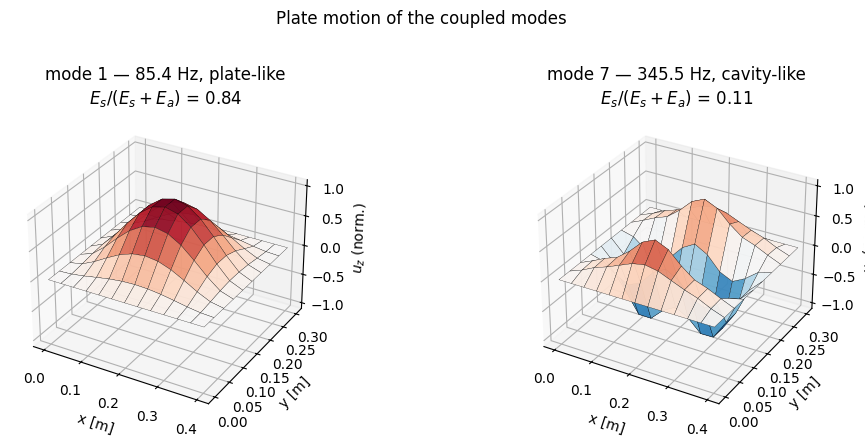

In [7]:
plate0 = system["structural"]["nodes0"]
# Gmsh coordinates carry round-off, so the grid lines are recovered from
# rounded values; the inverse indices then scatter any nodal field onto
# the structured plate grid.
xs, ix = np.unique(np.round(nodes[plate0, 0], 6), return_inverse=True)
ys, iy = np.unique(np.round(nodes[plate0, 1], 6), return_inverse=True)
X, Y = np.meshgrid(xs, ys)


def plate_shape(mode_vector):
    """Transverse displacement of the plate, on the structured plate grid."""
    field = structural_displacement_field(
        mode_vector[:ns], blocks_free["idx_s"], nodes.shape[0]
    )
    uz = np.zeros((ys.size, xs.size))
    uz[iy, ix] = np.real(field[plate0, 2])
    return uz / np.abs(uz).max()


i_plate = int(np.argmax(frac > 0.75))                       # first plate-like
i_cav = int(np.argmin(np.where(f_coupled > 1.0, frac, 9)))  # first cavity-like

fig = plt.figure(figsize=(11, 4.2))
for k, (idx, name) in enumerate([(i_plate, "plate-like"), (i_cav, "cavity-like")]):
    ax = fig.add_subplot(1, 2, k + 1, projection="3d")
    Z = plate_shape(modes[:, idx])
    ax.plot_surface(X, Y, Z, cmap="RdBu_r", vmin=-1, vmax=1,
                    linewidth=0.2, edgecolor="k", alpha=0.95)
    ax.set(xlabel="x [m]", ylabel="y [m]", zlabel="$u_z$ (norm.)", zlim=(-1.1, 1.1))
    ax.set_title(f"mode {idx} — {f_coupled[idx]:.1f} Hz, {name}\n"
                 f"$E_s/(E_s+E_a)$ = {frac[idx]:.2f}")
fig.suptitle("Plate motion of the coupled modes", y=1.02)
plt.tight_layout()
plt.show()

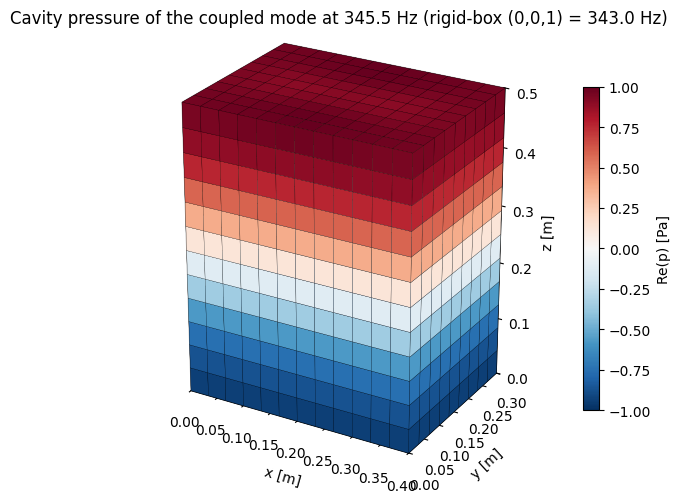

(<Figure size 700x600 with 2 Axes>,
 <Axes3D: title={'center': 'Cavity pressure of the coupled mode at 345.5 Hz (rigid-box (0,0,1) = 343.0 Hz)'}, xlabel='x [m]', ylabel='y [m]', zlabel='z [m]'>)

In [8]:
p_mode = expand_pressure(modes[ns:, i_cav], blocks_free["idx_a"], nodes.shape[0])
plot_pressure_3d(
    nodes, elements, p_mode / np.abs(p_mode).max(),
    part="real", cmap="RdBu_r", clim=(-1, 1),
    title=f"Cavity pressure of the coupled mode at {f_coupled[i_cav]:.1f} Hz "
          f"(rigid-box (0,0,1) = {C0 / (2 * LZ):.1f} Hz)",
)

## 6. Direct frequency response

Now the forced problem: 1 N normal at the centre of the plate, nothing applied to
the fluid. At every frequency `solve_vibroacoustic_frequency_sweep` assembles
$\mathbf A(\omega)$ and factorizes it — the matrix is complex **and** unsymmetric,
so nothing can be reused from one frequency to the next and the cost grows linearly
with the number of lines in the sweep.

Damping, without which the peaks would be infinite and the sweep would only measure
its own frequency resolution:

* **structure** — loss factor, $\mathbf K_s(1 + j\eta_s)$, via `eta_s`;
* **fluid** — the five walls get a large but finite normalized impedance
  $\zeta = 200$ (absorption $\alpha = 4\zeta/(1+\zeta)^2 \approx 2\%$), assembled by
  the standard acoustic BC layer and passed in as `C_a`.

In [9]:
# Acoustic damping: lightly lined walls -> C_a (frequency independent here)
bc_walls = AcousticBC().add_impedance("rigid_walls", ZETA_WALL)
C_a = build_impedance_operator(
    bc_walls, nodes=nodes, rho=RHO0, c0=C0,
    boundaries=boundaries, groups=groups, elements=elements, boundary_dim=2,
).at(0.0)
alpha = 4 * ZETA_WALL / (1 + ZETA_WALL) ** 2
print(f"C_a: {C_a.nnz} nnz, wall absorption coefficient alpha = {alpha:.3f}")

blocks = build_coupled_blocks(system, C_a=C_a, eta_s=ETA_S)

# Driving DOF: transverse translation of the node closest to the plate centre
idx_s = system["structural"]["idx_free"]
node_of_dof, component = idx_s // 6, idx_s % 6
centre = np.array([LX / 2, LY / 2, LZ])
plate_nodes = np.unique(node_of_dof)
drive_node = plate_nodes[np.argmin(
    np.linalg.norm(nodes[plate_nodes] - centre, axis=1)
)]
dof = int(np.where((node_of_dof == drive_node) & (component == 2))[0][0])

F_s = np.zeros(blocks["n_s"])
F_s[dof] = 1.0                      # 1 N along +z
print(f"drive at node {drive_node} {np.round(nodes[drive_node], 4)}, "
      f"reduced DOF {dof}")

frequencies = np.arange(F_MIN, F_MAX + DF, DF)
t0 = time.time()
result = solve_vibroacoustic_frequency_sweep(
    system, frequencies, F_s=F_s, blocks=blocks, verbose=False,
)
t_direct = time.time() - t0
print(f"direct sweep: {frequencies.size} frequencies, "
      f"{blocks['n_s'] + blocks['n_a']} unknowns, {t_direct:.1f} s "
      f"({1e3 * t_direct / frequencies.size:.0f} ms per frequency)")
print(f"for comparison, the 14 coupled modes took {t_modal:.2f} s")

C_a: 5572 nnz, wall absorption coefficient alpha = 0.020
drive at node 259 [0.2    0.1333 0.5   ], reduced DOF 260


direct sweep: 861 frequencies, 2218 unknowns, 26.4 s (31 ms per frequency)
for comparison, the 14 coupled modes took 0.03 s


### The same force on the plate alone

Solving $(\mathbf K_s(1+j\eta_s) - \omega^2\mathbf M_s)\mathbf w = \mathbf F_s$ with the
very same mesh and damping isolates what the air is responsible for.

In [10]:
K_sc = K_s.astype(complex) * (1.0 + 1j * ETA_S)
w_vacuo = np.array([
    spsolve((K_sc - (2 * np.pi * f) ** 2 * M_s).tocsc(), F_s.astype(complex))[dof]
    for f in frequencies
])

w_centre = result["w"][dof]

# Microphone in a corner of the cavity, away from any nodal plane
idx_a = result["idx_a"]
mic_node = idx_a[np.argmin(
    np.linalg.norm(nodes[idx_a] - np.array([0.02, 0.02, 0.02]), axis=1)
)]
mic_row = int(np.where(idx_a == mic_node)[0][0])
p_mic = result["p"][mic_row]
print(f"microphone at node {mic_node} {np.round(nodes[mic_node], 4)}")
print(f"peak |w| = {np.abs(w_centre).max():.3e} m, "
      f"peak |p| = {np.abs(p_mic).max():.1f} Pa")

microphone at node 128 [0.0333 0.0333 0.    ]
peak |w| = 2.529e-03 m, peak |p| = 227.8 Pa


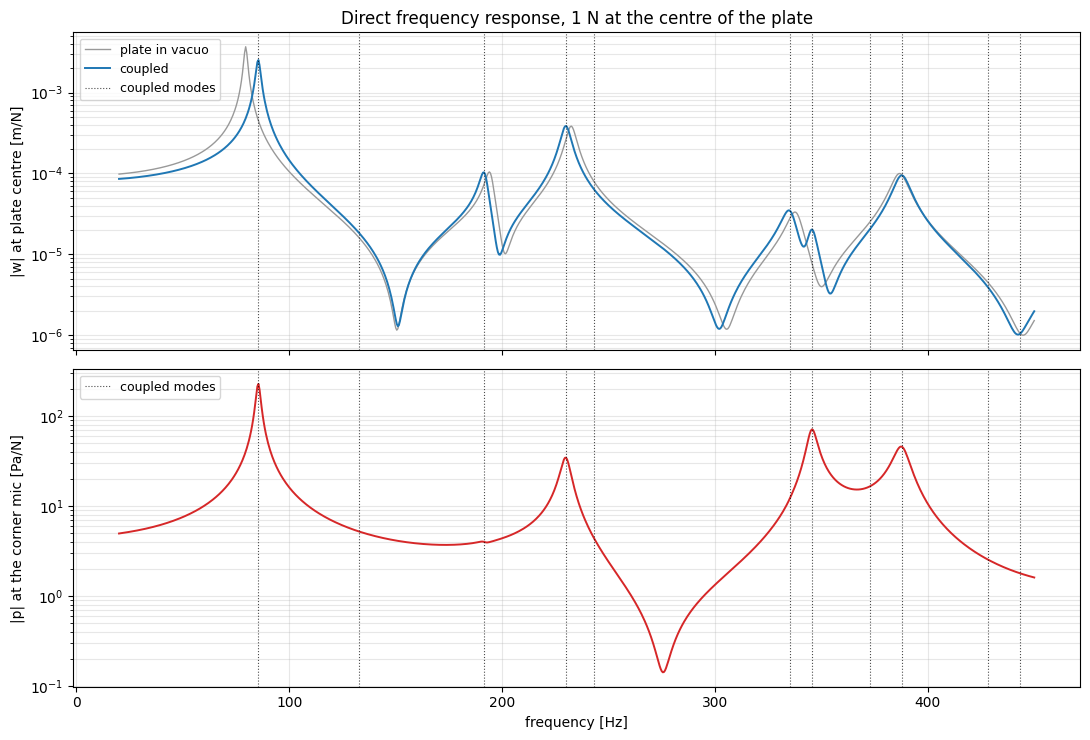

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True)

axes[0].semilogy(frequencies, np.abs(w_vacuo), lw=1.0, color="0.6",
                 label="plate in vacuo")
axes[0].semilogy(frequencies, np.abs(w_centre), lw=1.4, color="C0",
                 label="coupled")
axes[0].set_ylabel("|w| at plate centre [m/N]")
axes[0].set_title("Direct frequency response, 1 N at the centre of the plate")

axes[1].semilogy(frequencies, np.abs(p_mic), lw=1.4, color="C3")
axes[1].set(xlabel="frequency [Hz]", ylabel="|p| at the corner mic [Pa/N]")

for ax in axes:
    for k, f in enumerate(f_coupled[(f_coupled > F_MIN) & (f_coupled < F_MAX)]):
        ax.axvline(f, color="k", ls=":", lw=0.8, alpha=0.7,
                   label="coupled modes" if k == 0 else None)
    ax.grid(alpha=0.3, which="both")
    ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

## 7. Modal vs direct — the cross-check

Every peak of the direct sweep must land on a coupled natural frequency. The peak
positions are refined by fitting a parabola through the three points around each
local maximum, so the comparison is not limited by the 0.5 Hz step of the sweep.

Modes that are *missing* from the response are not an error: a point force at the
centre of the plate cannot excite a mode with a node line there, which is exactly
what happens to the modes antisymmetric in $x$ or $y$.

In [12]:
def find_peaks(freqs, response):
    """Local maxima of |response|, refined by a parabola on log amplitude."""
    a = np.log(np.abs(response) + 1e-300)
    out = []
    for i in range(1, freqs.size - 1):
        if a[i] > a[i - 1] and a[i] >= a[i + 1]:
            denom = a[i - 1] - 2 * a[i] + a[i + 1]
            shift = 0.5 * (a[i - 1] - a[i + 1]) / denom if denom != 0 else 0.0
            out.append(freqs[i] + shift * (freqs[1] - freqs[0]))
    return np.array(out)


peaks_w = find_peaks(frequencies, w_centre)
peaks_p = find_peaks(frequencies, p_mic)

# Merge the two peak lists: the same resonance shows up in both signals.
rows = [[f, {"w"}] for f in peaks_w]
for f in peaks_p:
    near = [r for r in rows if abs(r[0] - f) < 1.0]
    if near:
        near[0][1].add("p")
    else:
        rows.append([f, {"p"}])
rows.sort()

print("  peak of the sweep     seen in    nearest coupled mode      difference")
for f_pk, seen in rows:
    j = int(np.argmin(np.abs(f_coupled - f_pk)))
    kind = ("plate-like " if frac[j] > 0.75 else
            "cavity-like" if frac[j] < 0.25 else "coupled    ")
    print(f"  {f_pk:8.2f} Hz          {'+'.join(sorted(seen)):<4}    "
          f"{f_coupled[j]:8.2f} Hz  ({kind})   {f_pk - f_coupled[j]:+6.2f} Hz")

all_peaks = np.array([r[0] for r in rows])
missed = [f for f in f_coupled[(f_coupled > F_MIN) & (f_coupled < F_MAX)]
          if np.min(np.abs(all_peaks - f)) > 1.0]
print("\nmodes not excited by a force at the centre (node line there): "
      f"{np.round(missed, 2)} Hz")

  peak of the sweep     seen in    nearest coupled mode      difference
     85.39 Hz          p+w        85.41 Hz  (plate-like )    -0.01 Hz
    191.32 Hz          p+w       191.70 Hz  (plate-like )    -0.37 Hz
    229.90 Hz          p+w       229.89 Hz  (plate-like )    +0.02 Hz
    334.70 Hz          w         335.24 Hz  (plate-like )    -0.54 Hz
    345.52 Hz          p+w       345.51 Hz  (cavity-like)    +0.01 Hz
    387.74 Hz          p+w       387.74 Hz  (plate-like )    +0.01 Hz

modes not excited by a force at the centre (node line there): [132.61 243.16 372.82 428.2  443.41] Hz


## 8. Pressure field at resonance

The two peaks look nothing alike inside the cavity. On the plate-like resonance the
plate drives the air as a piston and the pressure is nearly uniform over the depth;
on the cavity-like one the field is the standing wave of the box, with its node
plane halfway up. Magnitudes are plotted rather than real parts: at a resonance the
response is in quadrature with the force, so `part="real"` would show mostly the
off-resonance remainder.

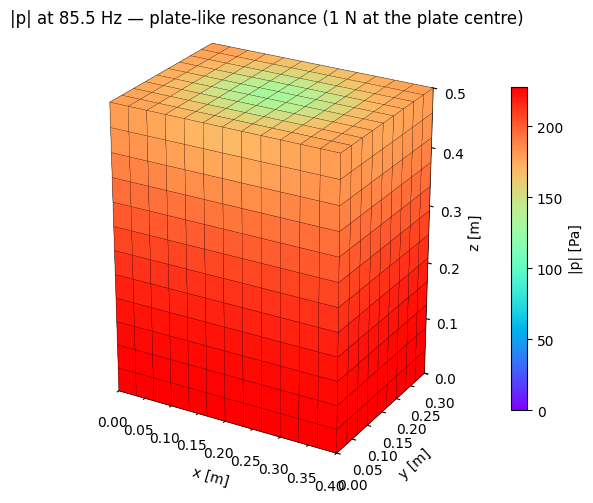

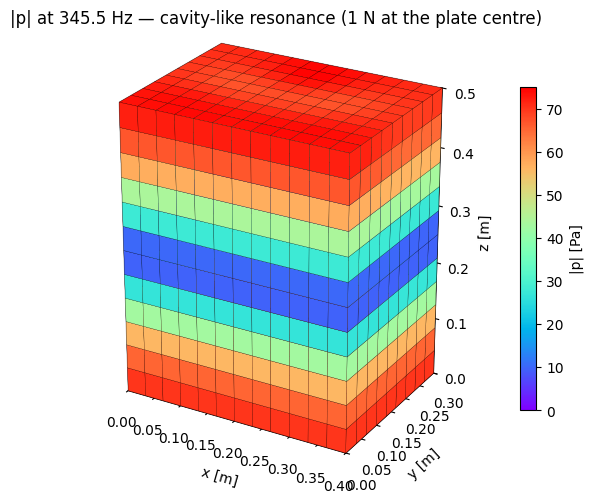

In [13]:
p_full = expand_pressure(result["p"], result["idx_a"], nodes.shape[0])

for f_target, name in [(f_coupled[i_plate], "plate-like"),
                       (f_coupled[i_cav], "cavity-like")]:
    k = int(np.argmin(np.abs(frequencies - f_target)))
    plot_pressure_3d(
        nodes, elements, p_full[:, k], part="abs",
        title=f"|p| at {frequencies[k]:.1f} Hz — {name} resonance "
              f"(1 N at the plate centre)",
    )

## 9. Two optional reduced models

Everything above used the **direct** solver: exact, one factorization per
frequency, 861 factorizations for the sweep. When that becomes the bottleneck,
the response can be expanded on a small basis instead,

$$\mathbf q = \begin{Bmatrix}\mathbf w\\ \mathbf p\end{Bmatrix}
\simeq \mathbf \Phi\, \boldsymbol\varphi , \qquad m \ll n_s + n_a ,$$

and an $m \times m$ system solved at each frequency. Two bases are available.
Neither is required to run a coupled analysis — they are accelerations, and the
direct solver stays the reference to check them against.

| | Cost to build | Efficiency per vector |
|---|---|---|
| **9a** Modal expansion on the coupled modes | high — one unsymmetric eigenproblem | high |
| **9b** Component Mode Synthesis | low — two symmetric eigenproblems | lower, needs more vectors |

Both feed the same solver, `solve_coupled_modal_frequency_sweep`.

### 9a. Modal expansion on the coupled modes

The basis is the set of coupled modes already computed in section 4 — each one a
structural shape *together with* its pressure field:

$$\mathbf q \simeq \sum_{c=1}^{m_c}\varphi_c
\begin{Bmatrix}\mathbf \Phi_{s,c}\\ \mathbf \Phi_{a,c}\end{Bmatrix}.$$

Because the coupled matrices are unsymmetric, the eigenproblem has **two**
families of eigenvectors, right and left,

$$\mathbf K \mathbf \Phi^R_c = \omega_c^2 \mathbf M \mathbf \Phi^R_c ,
\qquad
\mathbf K^T \mathbf \Phi^L_c = \omega_c^2 \mathbf M^T \mathbf \Phi^L_c ,$$

and the projection must use both, $(\mathbf \Phi^L)^T \mathbf A \mathbf \Phi^R$.
The left ones cost nothing extra here: for this block structure they follow from
the right ones without a second eigensolve,

$$\mathbf \Phi^L_c = \begin{Bmatrix}\rho_0\,\omega_c^2\,\mathbf \Phi_{s,c}\\
\mathbf \Phi_{a,c}\end{Bmatrix}$$

— same acoustic part, structural part scaled by $\rho_0\omega_c^2$.

Right modes are *not* orthogonal to one another. What holds is **biorthogonality**
between the two families, $(\mathbf \Phi^L_i)^T \mathbf M \mathbf \Phi^R_j = 0$ for
$i \neq j$, so normalizing the diagonal to 1 gives

$$\tilde{\mathbf M} = \mathbf I , \qquad
\tilde{\mathbf K} = \mathrm{diag}(\omega_c^2) .$$

Damping is not diagonalized by the same argument — the lined walls couple the
modes — so the $m_c \times m_c$ system is solved dense at every frequency.

In [14]:
blocks_undamped = build_coupled_blocks(system, C_a=C_a)   # eta_s belongs to the sweep

t0 = time.time()
coupled_basis = build_coupled_modal_basis(blocks=blocks_undamped, num_modes=40)
t_basis_coupled = time.time() - t0

m_c = coupled_basis["Phi_R"].shape[1]
print(f"{m_c} coupled modes up to {coupled_basis['freqs'].max():.0f} Hz, "
      f"built in {t_basis_coupled:.2f} s "
      f"(full model: {blocks_undamped['n_s'] + blocks_undamped['n_a']} unknowns)")

# The projected matrices are computed, not assumed: this is the check.
Kt, Ct, Mt = project_coupled_system(coupled_basis, eta_s=ETA_S)
omega2 = coupled_basis["omegas"] ** 2

print(f"biorthogonality residual        : "
      f"{coupled_basis['biorthogonality']:.1e}")
print(f"max |Mt - I|                    : "
      f"{np.abs(Mt - np.eye(m_c)).max():.1e}")
print(f"max |Re(Kt) - diag(omega_c^2)| / max(omega_c^2) : "
      f"{np.abs(np.real(Kt) - np.diag(omega2)).max() / omega2.max():.1e}")

off = np.abs(Ct - np.diag(np.diag(Ct)))
print(f"damping: largest off-diagonal / largest diagonal : "
      f"{off.max() / np.abs(np.diag(Ct)).max():.2f}  "
      "(the lined walls couple the modes, so Ct is dense)")

40 coupled modes up to 1112 Hz, built in 0.06 s (full model: 2218 unknowns)
biorthogonality residual        : 5.1e-04
max |Mt - I|                    : 5.1e-04
max |Re(Kt) - diag(omega_c^2)| / max(omega_c^2) : 2.1e-04
damping: largest off-diagonal / largest diagonal : 0.47  (the lined walls couple the modes, so Ct is dense)


In [15]:
t0 = time.time()
res_modal = solve_coupled_modal_frequency_sweep(
    coupled_basis, frequencies, F_s=F_s, eta_s=ETA_S, return_modal=True,
)
t_modal_sweep = time.time() - t0

err_w = np.linalg.norm(res_modal["w"] - result["w"]) / np.linalg.norm(result["w"])
err_p = np.linalg.norm(res_modal["p"] - result["p"]) / np.linalg.norm(result["p"])
print(f"direct           : {frequencies.size} solves of {blocks['n_s'] + blocks['n_a']} "
      f"unknowns   {t_direct:6.2f} s")
print(f"modal expansion  : {frequencies.size} solves of {m_c:4d} "
      f"unknowns   {t_modal_sweep:6.2f} s   ({t_direct / t_modal_sweep:.0f}x)")
print(f"                   error   w {err_w:.1e}   p {err_p:.1e}")

direct           : 861 solves of 2218 unknowns    26.35 s
modal expansion  : 861 solves of   40 unknowns     0.03 s   (945x)
                   error   w 2.0e-02   p 1.1e-02


The participation factors $\varphi_c(\omega)$ say which modes are actually doing
the work, and they are the cheapest diagnostic the modal path gives for free: each
peak of the response is one mode taking over.

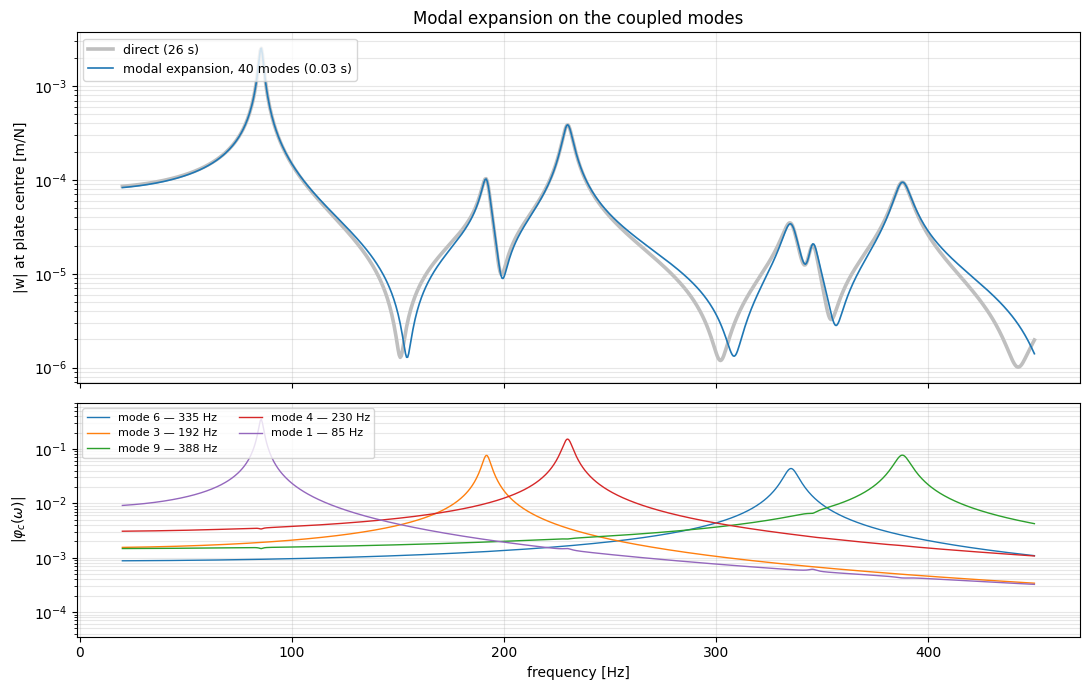

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7.0), sharex=True,
                         gridspec_kw={"height_ratios": [3, 2]})

axes[0].semilogy(frequencies, np.abs(w_centre), lw=2.6, color="0.75",
                 label=f"direct ({t_direct:.0f} s)")
axes[0].semilogy(frequencies, np.abs(res_modal["w"][dof]), lw=1.2, color="C0",
                 label=f"modal expansion, {m_c} modes ({t_modal_sweep:.2f} s)")
axes[0].set(ylabel="|w| at plate centre [m/N]",
            title="Modal expansion on the coupled modes")
axes[0].legend(loc="upper left", fontsize=9)

phi = np.abs(res_modal["participations"])
for c in np.argsort(phi.max(axis=1))[-5:]:
    axes[1].semilogy(frequencies, phi[c], lw=1.0,
                     label=f"mode {c} — {coupled_basis['freqs'][c]:.0f} Hz")
axes[1].set(xlabel="frequency [Hz]", ylabel=r"$|\varphi_c(\omega)|$",
            ylim=(phi.max() * 1e-4, phi.max() * 2))
axes[1].legend(loc="upper left", fontsize=8, ncol=2)

for ax in axes:
    ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

### 9b. Component Mode Synthesis

CMS never forms the coupled eigenproblem. The two components are solved
separately, both **symmetric**,

$$\mathbf K_s \mathbf \Phi_{su} = \omega_{s}^2\,\mathbf M_s \mathbf \Phi_{su} ,
\qquad
\mathbf K_a \mathbf \Phi_{au} = \omega_{a}^2\,\mathbf M_a \mathbf \Phi_{au} ,$$

the **dry** plate (no pressure load on its face) and the cavity with **rigid
walls**, and their modes are stacked block-diagonally:

$$\begin{Bmatrix}\mathbf w\\ \mathbf p\end{Bmatrix} =
\begin{bmatrix}\mathbf \Phi_{su} & \mathbf 0\\ \mathbf 0 & \mathbf \Phi_{au}\end{bmatrix}
\begin{Bmatrix}\boldsymbol\varphi_s\\ \boldsymbol\varphi_a\end{Bmatrix}.$$

The coupling comes back only in the reduced matrices,

$$\tilde{\mathbf K} = \begin{bmatrix}\mathbf \Lambda_s & -\mathbf A\\
\mathbf 0 & \mathbf \Lambda_a\end{bmatrix},\qquad
\tilde{\mathbf M} = \begin{bmatrix}\mathbf I_s & \mathbf 0\\
\rho_0 \mathbf A^T & \mathbf I_a\end{bmatrix},\qquad
\mathbf A = \mathbf \Phi_{su}^T \mathbf K_c \mathbf \Phi_{au} ,$$

which are still coupled and still unsymmetric: normalizing each component
diagonalizes its own block, nothing more.

In [17]:
t0 = time.time()
cms_basis = build_cms_basis(blocks=blocks_undamped,
                            num_structural=15, num_acoustic=40)
t_basis_cms = time.time() - t0

m_s, m_a = cms_basis["num_structural"], cms_basis["num_acoustic"]
print(f"{m_s + m_a} vectors ({m_s} dry plate + {m_a} rigid cavity), "
      f"built in {t_basis_cms:.2f} s")
print(f"  dry plate    : {np.round(cms_basis['omegas_s'][:5] / (2 * np.pi), 1)} Hz"
      "   (= the in-vacuo frequencies of section 3)")
print(f"  rigid cavity : {np.round(cms_basis['omegas_a'][:5] / (2 * np.pi), 1)} Hz"
      "   (0 Hz = uniform pressure of the sealed cavity)")

# Check the reduced matrices against the block form written above.
Kt_cms, _, Mt_cms = project_coupled_system(cms_basis)
A = cms_basis["modal_coupling"]
Kt_theory = np.block([[np.diag(cms_basis["omegas_s"] ** 2), -A],
                      [np.zeros((m_a, m_s)), np.diag(cms_basis["omegas_a"] ** 2)]])
Mt_theory = np.block([[np.eye(m_s), np.zeros((m_s, m_a))],
                      [RHO0 * A.T, np.eye(m_a)]])
print(f"max |Kt - [[Ls, -A], [0, La]]| / max|Kt| : "
      f"{np.abs(Kt_cms - Kt_theory).max() / np.abs(Kt_theory).max():.1e}")
print(f"max |Mt - [[I, 0], [rho0 A^T, I]]|       : "
      f"{np.abs(Mt_cms - Mt_theory).max():.1e}")

55 vectors (15 dry plate + 40 rigid cavity), built in 0.05 s
  dry plate    : [ 79.5 134.9 194.4 232.4 245.7] Hz   (= the in-vacuo frequencies of section 3)
  rigid cavity : [  0.  344.  430.  550.6 574.6] Hz   (0 Hz = uniform pressure of the sealed cavity)
max |Kt - [[Ls, -A], [0, La]]| / max|Kt| : 1.5e-14
max |Mt - [[I, 0], [rho0 A^T, I]]|       : 2.3e-13


$A_{ij}$ measures how much dry plate mode $i$ and rigid cavity mode $j$ drive each
other: how well that plate shape moves the air the way that cavity mode wants to
move, and how much work that pressure field does on that plate shape. Its pattern
is a set of selection rules — most pairs simply do not talk.

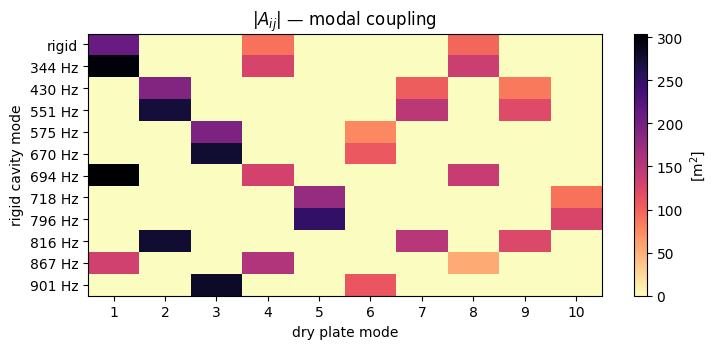

coupling to the uniform-pressure mode, plate modes 1-6:
[-210.307    -0.        0.       90.0983    0.       -0.    ]


In [18]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
im = ax.imshow(np.abs(A[:10, :12]).T, cmap="magma_r", aspect="auto")
ax.set(xlabel="dry plate mode", ylabel="rigid cavity mode",
       title="$|A_{ij}|$ — modal coupling")
ax.set_xticks(range(10), [str(i + 1) for i in range(10)])
ax.set_yticks(range(12), ["rigid"] + [f"{f:.0f} Hz" for f in
                                      cms_basis["omegas_a"][1:12] / (2 * np.pi)])
fig.colorbar(im, ax=ax, label="[m$^2$]")
plt.tight_layout()
plt.show()

# The uniform-pressure mode is the air spring: it couples to the plate modes that
# change the volume of the cavity, and to no other.
print("coupling to the uniform-pressure mode, plate modes 1-6:")
print(np.round(A[:6, 0], 4))

In [19]:
t0 = time.time()
res_cms = solve_coupled_modal_frequency_sweep(
    cms_basis, frequencies, F_s=F_s, eta_s=ETA_S,
)
t_cms_sweep = time.time() - t0

err_w_cms = np.linalg.norm(res_cms["w"] - result["w"]) / np.linalg.norm(result["w"])
err_p_cms = np.linalg.norm(res_cms["p"] - result["p"]) / np.linalg.norm(result["p"])
print(f"CMS : {frequencies.size} solves of {m_s + m_a:4d} unknowns   "
      f"{t_cms_sweep:6.2f} s   ({t_direct / t_cms_sweep:.0f}x)")
print(f"      error   w {err_w_cms:.1e}   p {err_p_cms:.1e}   "
      f"(modal expansion, {m_c} vectors: w {err_w:.1e})")

CMS : 861 solves of   55 unknowns     0.04 s   (669x)
      error   w 3.0e-01   p 2.7e-01   (modal expansion, 40 vectors: w 2.0e-02)


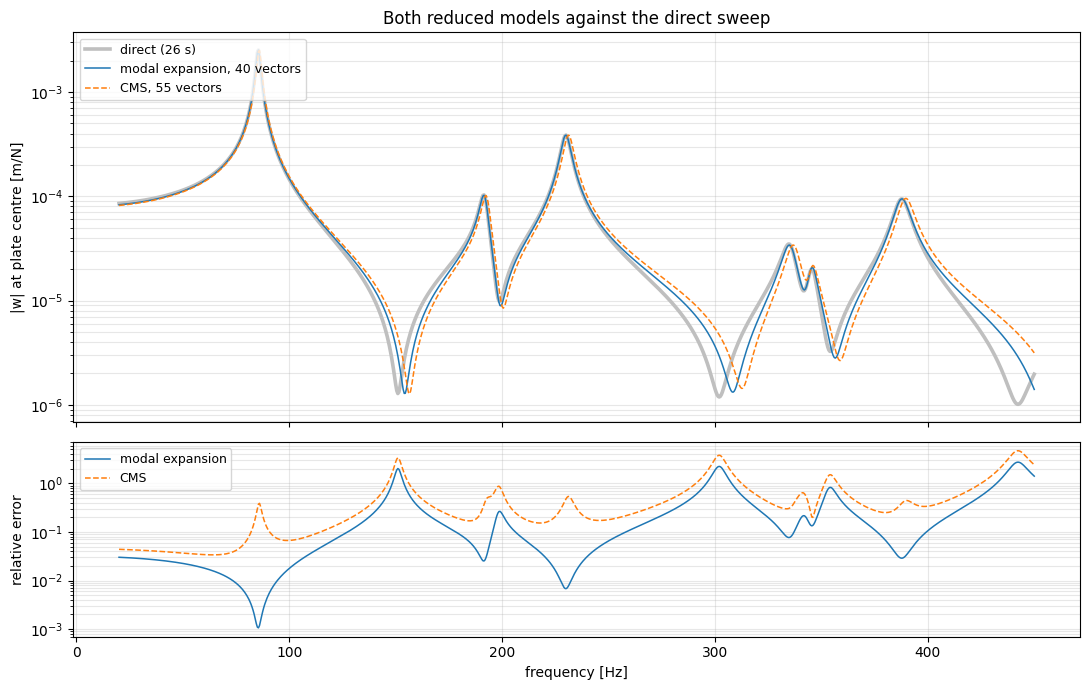

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7.0), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})

axes[0].semilogy(frequencies, np.abs(w_centre), lw=2.6, color="0.75",
                 label=f"direct ({t_direct:.0f} s)")
axes[0].semilogy(frequencies, np.abs(res_modal["w"][dof]), "-", lw=1.1,
                 color="C0", label=f"modal expansion, {m_c} vectors")
axes[0].semilogy(frequencies, np.abs(res_cms["w"][dof]), "--", lw=1.1,
                 color="C1", label=f"CMS, {m_s + m_a} vectors")
axes[0].set(ylabel="|w| at plate centre [m/N]",
            title="Both reduced models against the direct sweep")
axes[0].legend(loc="upper left", fontsize=9)

for res, style, color, name in ((res_modal, "-", "C0", "modal expansion"),
                                (res_cms, "--", "C1", "CMS")):
    axes[1].semilogy(frequencies,
                     np.abs(res["w"][dof] - w_centre) / np.abs(w_centre),
                     style, lw=1.1, color=color, label=name)
axes[1].set(xlabel="frequency [Hz]", ylabel="relative error")
axes[1].legend(loc="upper left", fontsize=9)

for ax in axes:
    ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

### 9c. How the two converge

The comparison to make is at **equal number of vectors**, since that is what sets
the cost of the reduced solve.

In [21]:
def reduced_error(basis):
    """Relative error of a reduced model against the direct sweep."""
    t0 = time.time()
    r = solve_coupled_modal_frequency_sweep(
        basis, frequencies, F_s=F_s, eta_s=ETA_S,
    )
    t = time.time() - t0
    return (np.linalg.norm(r["w"] - result["w"]) / np.linalg.norm(result["w"]),
            np.linalg.norm(r["p"] - result["p"]) / np.linalg.norm(result["p"]),
            np.median(np.abs(r["w"][dof] - w_centre) / np.abs(w_centre)), t)


history = {"modal expansion": [], "CMS": []}
print(" basis              vectors   err w    err p   err at drive   basis    sweep")
for m in (10, 20, 40, 80):
    t0 = time.time()
    b = build_coupled_modal_basis(blocks=blocks_undamped, num_modes=m)
    tb = time.time() - t0
    ew, ep, ed, ts = reduced_error(b)
    history["modal expansion"].append((m, ew))
    print(f" modal expansion    {m:5d}   {ew:.1e}  {ep:.1e}     {ed:.1e}    "
          f"{tb:5.2f} s  {ts:5.2f} s")

for ms, ma in ((5, 15), (10, 30), (20, 60), (40, 160)):
    t0 = time.time()
    b = build_cms_basis(blocks=blocks_undamped,
                        num_structural=ms, num_acoustic=ma)
    tb = time.time() - t0
    ew, ep, ed, ts = reduced_error(b)
    history["CMS"].append((ms + ma, ew))
    print(f" CMS {ms:3d}s + {ma:3d}a    {ms + ma:5d}   {ew:.1e}  {ep:.1e}     "
          f"{ed:.1e}    {tb:5.2f} s  {ts:5.2f} s")

 basis              vectors   err w    err p   err at drive   basis    sweep


 modal expansion       10   5.2e-02  1.6e-02     3.5e-01     0.03 s   0.01 s


 modal expansion       20   2.7e-02  1.5e-02     1.6e-01     0.04 s   0.01 s
 modal expansion       40   2.0e-02  1.1e-02     1.1e-01     0.06 s   0.02 s


/Users/danielefabbri/Desktop/pycafe_new/pycafe/solver/solver_vibroacoustic_modal.py:584: RuntimeWarning: The basis reaches 387.7 Hz, below the usual 2 x f_max = 900.0 Hz rule; the response near the top of the sweep is likely truncated.
  warnings.warn(
/Users/danielefabbri/Desktop/pycafe_new/pycafe/solver/solver_vibroacoustic_modal.py:584: RuntimeWarning: The basis reaches 683.5 Hz, below the usual 2 x f_max = 900.0 Hz rule; the response near the top of the sweep is likely truncated.
  warnings.warn(


 modal expansion       80   1.4e-02  9.8e-03     5.7e-02     0.09 s   0.06 s
 CMS   5s +  15a       20   5.2e-01  6.0e-01     6.8e-01     0.03 s   0.01 s
 CMS  10s +  30a       40   3.5e-01  3.2e-01     4.7e-01     0.04 s   0.02 s


 CMS  20s +  60a       80   2.3e-01  2.0e-01     2.5e-01     0.06 s   0.06 s


 CMS  40s + 160a      200   1.3e-01  1.2e-01     1.0e-01     0.15 s   0.30 s


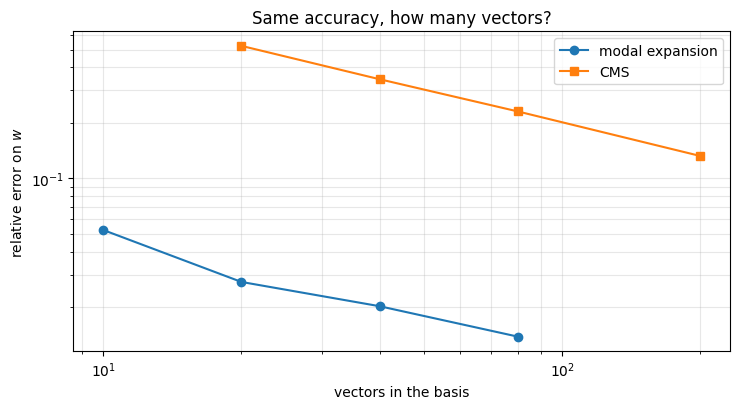

In [22]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for name, marker in (("modal expansion", "o"), ("CMS", "s")):
    sizes, errs = zip(*history[name])
    ax.loglog(sizes, errs, marker + "-", label=name)
ax.set(xlabel="vectors in the basis", ylabel="relative error on $w$",
       title="Same accuracy, how many vectors?")
ax.grid(alpha=0.3, which="both")
ax.legend()
plt.tight_layout()
plt.show()

The ranking is the one the theory predicts, and the reason is physical. A CMS
acoustic mode is computed with a **rigid** interface, $u_{f,n} = 0$, while the true
condition there is $u_{f,n} = u_{s,n}$: the field a vibrating plate produces near
its own surface is largely evanescent, with strong normal gradients, and global
rigid-wall modes rebuild it slowly. So CMS buys a cheap basis and pays for it in
size — while the coupled modes, which already know about the interface, are worth
far more per vector but need the unsymmetric eigenproblem solved first.

Two refinements exist for the CMS side, neither implemented here: acoustic modes
computed with an **impedance** condition on the interface instead of a rigid wall —
efficient, but choosing $Z$ is an open question, since $Z \to \infty$ falls back to
the rigid wall and $Z \to 0$ to a pressure-release surface — and **fixed-interface
modes** ($p = 0$ on the interface) plus one **constraint mode** per interface DOF,
exact in principle but adding up to $N_\Gamma$ vectors, which leaves little
reduction on a finely meshed interface.

Note what neither basis fixes: the error is largest **at the driven point**, and at
the anti-resonances, where the response is a cancellation between modes. The
vectors left out still carry a quasi-static flexibility that a point load — broad
in space — excites strongly. Judge convergence on a global norm or away from the
drive, and keep the direct solver as the reference.

## What to take away

* **One matrix does the coupling.** $\mathbf K_c$ is built once, on the shared faces
  of a conforming mesh, and reused by both solvers. Its column sum is the vector
  area of the interface — check it before trusting anything downstream.
* **The modes explain the response.** Every peak of the direct sweep sits on a
  coupled natural frequency to well under a hertz, and the energy split says whether
  the peak is the plate, the air, or both.
* **Sealed air is a spring.** The first CCCC plate mode moves up by several percent;
  higher modes, which slosh the air rather than compress it, move down instead.
* **The direct sweep is the expensive part.** The complex unsymmetric matrix has to
  be factorized once per frequency, while the whole modal analysis costs a fraction
  of a second — the reason modal methods exist, and the reason a fine sweep is
  usually run only where the modes say something happens.
* **Reduction is optional, and it is a trade.** Both bases turn a 28 s sweep into a
  fraction of a second, the coupled modes at a few 1e-3 of error with 40 vectors,
  CMS needing several times more for the same — cheap basis, less efficient basis.
* **Watch the resolution.** With $\eta_s = 0.02$ a peak at 100 Hz is about 2 Hz wide:
  a coarser step than that does not shift the peak, it just misses its height.

### Limits of this model

* The cavity is sealed and the walls are almost rigid — no radiation to the outside,
  so nothing here is a transmission-loss calculation.
* Damping is a loss factor plus a lined wall, not a measured material model.
* The mesh is accurate to ~1% up to roughly $c_0/(13h) \approx 650$ Hz for the fluid;
  the plate discretization is the tighter limit at high frequency, where the modal
  density of the plate grows first.

**See also** — `cquad4_plate_validation.ipynb` (the shell element against Nastran and
Leissa), `hexa8_cavity_validation.ipynb` (the acoustic element against the exact
cavity modes), `acoustic_response_2d_3d.ipynb` (all acoustic boundary conditions,
direct *and* modal superposition on the uncoupled fluid).